# Machine Information

In [1]:
gpu_info = !nvidia-smi
gpu_info = '\n'.join(gpu_info)
if gpu_info.find('failed') >= 0:
  print('Not connected to a GPU')
else:
  print(gpu_info)

Mon Jun 20 12:55:17 2022       
+-----------------------------------------------------------------------------+
| NVIDIA-SMI 460.32.03    Driver Version: 460.32.03    CUDA Version: 11.2     |
|-------------------------------+----------------------+----------------------+
| GPU  Name        Persistence-M| Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp  Perf  Pwr:Usage/Cap|         Memory-Usage | GPU-Util  Compute M. |
|                               |                      |               MIG M. |
|===============================+======================+======================|
|   0  Tesla P100-PCIE...  Off  | 00000000:00:04.0 Off |                    0 |
| N/A   36C    P0    27W / 250W |      0MiB / 16280MiB |      0%      Default |
|                               |                      |                  N/A |
+-------------------------------+----------------------+----------------------+
                                                                               
+-------

In [2]:
from psutil import virtual_memory
ram_gb = virtual_memory().total / 1e9
print('Your runtime has {:.1f} gigabytes of available RAM\n'.format(ram_gb))

if ram_gb < 20:
  print('Not using a high-RAM runtime')
else:
  print('You are using a high-RAM runtime!')

Your runtime has 27.3 gigabytes of available RAM

You are using a high-RAM runtime!


# Clone Github Repo

In [3]:
!git clone https://github.com/ultralytics/yolov5
%cd yolov5

Cloning into 'yolov5'...
remote: Enumerating objects: 12265, done.
remote: Counting objects: 100% (15/15), done.
remote: Compressing objects: 100% (14/14), done.
remote: Total 12265 (delta 3), reused 6 (delta 1), pack-reused 12250
Receiving objects: 100% (12265/12265), 12.01 MiB | 15.14 MiB/s, done.
Resolving deltas: 100% (8489/8489), done.
/content/yolov5


In [4]:
import utils

utils.notebook_init()

YOLOv5 🚀 v6.1-258-g1156a32 Python-3.7.13 torch-1.11.0+cu113 CUDA:0 (Tesla P100-PCIE-16GB, 16281MiB)


Setup complete ✅ (4 CPUs, 25.5 GB RAM, 38.8/166.8 GB disk)


<module 'IPython.display' from '/usr/local/lib/python3.7/dist-packages/IPython/display.py'>

# Install Library

In [5]:
!python -m pip install rich

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
     |████████████████████████████████| 232 kB 7.3 MB/s 
     |████████████████████████████████| 51 kB 9.0 MB/s 


In [6]:
!pip install --upgrade --no-cache-dir gdown

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/


In [7]:
!pip install -r requirements.txt

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
     |████████████████████████████████| 596 kB 7.2 MB/s 
  Attempting uninstall: PyYAML
    Found existing installation: PyYAML 3.13
    Uninstalling PyYAML-3.13:
      Successfully uninstalled PyYAML-3.13


In [8]:
!pip install validators

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
  Created wheel for validators: filename=validators-0.20.0-py3-none-any.whl size=19582 sha256=20ba9d0f783b87f134882fe3c2a7b399ea63562b015c6a4637289de9a004bc98
  Stored in directory: /root/.cache/pip/wheels/5f/55/ab/36a76989f7f88d9ca7b1f68da6d94252bb6a8d6ad4f18e04e9
Successfully built validators


In [9]:
!pip install alive-progress

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
     |████████████████████████████████| 80 kB 5.5 MB/s 
     |████████████████████████████████| 207 kB 17.0 MB/s 
  Created wheel for grapheme: filename=grapheme-0.6.0-py3-none-any.whl size=210096 sha256=27bdcc7e59c425b5f22bac6ad4b9509b0f0589e21809601c362e3bf6324d8680
  Stored in directory: /root/.cache/pip/wheels/71/fc/c8/142ef03b79c02b618fe80b9f2d01c25bd55f60b0c58eab3f0e
Successfully built grapheme


In [10]:
# !pip install googledrivedownloader

# Import Library

In [11]:
import os
import cv2
import time
import gdown
import shutil
import random
import inspect
import zipfile
import datetime
import validators
import numpy as np
import collections
from tqdm import tqdm
from rich.table import Table
from PIL import ImageEnhance
from google.colab import drive
from google.colab import files
from rich.console import Console
from IPython.display import Image
from alive_progress import alive_bar
from PIL.Image import open as image_open
from google.colab.patches import cv2_imshow
from google_drive_downloader import GoogleDriveDownloader as gdd

# Config

In [12]:
""" PATH """
# ROOT_DATASET = "/content/drive/MyDrive/02.Data/YOLOv5_Anime-Facial-Expression"
# ROOT_DATASET = "https://drive.google.com/uc?id=1dgyTFihlC-C9muIggkilHMY7I2nDnjTX"
# ZIP_NAME = "YOLOv5_FER2013.zip"

ROOT_DRIVE = "/content/drive/MyDrive/02.Data/PROCESSED/YOLOv5-Anime_Head_Detection"
NAME_IN_SAVED_MODEL = "Anime_Head_Detection"
ROOT = "/content/yolov5"
PATH_CLASSES = os.path.join(ROOT_DRIVE, "classes.txt")
PATH_IMAGES = os.path.join(ROOT_DRIVE, "images")
PATH_LABELS = os.path.join(ROOT_DRIVE, "labels")
PRETRAINED_SAVED_PATH = os.path.join(ROOT_DRIVE, "pretrained")

PATH_BACKGROUND = "/content/drive/MyDrive/02.Data/PROCESSED/Background_No_Human_Face"

In [13]:
""" TRAIN """
SPLIT_PORTION = (0.8, 0.2, 0) # train-validation-test

BASE_MODEL = "yolov5x6.yaml"
WEIGHTS = BASE_MODEL.replace("yaml", "pt")
BACKGROUND_PORTION = 0.1
BATCH = 4
IMG = 1280
EPOCHS = 500
PATIENCE = 100

In [14]:
PRETRAINED_SAVED_NAME = BASE_MODEL.replace("yolo", "YOLO").replace(".yaml", "")
PRETRAINED_SAVED_NAME

'YOLOv5x6'

In [15]:
now = datetime.datetime.now()
month = now.month
if month < 10:
  month = f"0{month}"

day = now.day
if day < 10:
  day = f"0{day}"

date = f"{now.year}.{month}.{day}"

# Get Dataset

In [16]:
def get_dataset(NEW_ROOT_DATASET=None, ROOT_DATASET=None, ZIP_NAME=None, mode=0):
  if mode == 0:
    drive.mount('/content/drive')

  elif mode == 1:
    print(NEW_ROOT_DATASET, ROOT_DATASET, ZIP_NAME)
    if validators.url(ROOT_DATASET):
      assert ZIP_NAME != None
      gdown.download(ROOT_DATASET, ZIP_NAME, quiet=False)
      shutil.unpack_archive(ZIP_NAME, NEW_ROOT_DATASET)
      for root, directories, files in os.walk(NEW_ROOT_DATASET):
        for dir in directories:
          if dir == "images":
            NEW_ROOT_DATASET = root
            break
    else:
      drive.mount('/content/drive')
      shutil.copytree(ROOT_DATASET, NEW_ROOT_DATASET) 

    return  os.path.join(NEW_ROOT_DATASET, "classes.txt"), \
            os.path.join(NEW_ROOT_DATASET, "images"), \
            os.path.join(NEW_ROOT_DATASET, "labels"), \
            os.path.join(NEW_ROOT_DATASET, "pretrained")

In [17]:
get_dataset()

Mounted at /content/drive


In [18]:
# if validators.url(ROOT_DATASET):
#   # print(ROOT_DATASET.split("uc?id=")[-1])
#   zip_name = f"{NEW_ROOT_DATASET}.zip"
#   print(zip_name)
#   gdown.download(ROOT_DATASET, zip_name, quiet=False)
#   # gdd.download_file_from_google_drive(file_id=ROOT_DATASET.split("uc?id=")[-1],
#   #                                     dest_path=zip_name)
#   shutil.unpack_archive(zip_name, NEW_ROOT_DATASET)

In [19]:
# if "drive" in ROOT_DATASET:
#   # https://drive.google.com/uc?id=1dgyTFihlC-C9muIggkilHMY7I2nDnjTX
#   # drive.mount('/content/drive')
#   shutil.copytree(ROOT_DATASET, NEW_ROOT_DATASET) 
# elif "zip" in ROOT_DATASET:
#   with zipfile.ZipFile(ROOT_DATASET, "r") as zip_ref:
#       zip_ref.extractall(ROOT)

# Get Latest Pretrained Path

In [20]:
def get_latest_pretrained_model(pretrained_saved_path):
  pretrained_models = []
  for root, directories, files in os.walk(pretrained_saved_path):
    for file in files:
      if file.endswith(".pt"):
        pretrained_models.append((root, file))
  if len(pretrained_models) != 0:
    return os.path.join(pretrained_saved_path, sorted(pretrained_models)[-1][0], sorted(pretrained_models)[-1][1])
  else:
    return None

In [21]:
LATEST_PRETRAINED_MODEL_PATH = get_latest_pretrained_model(pretrained_saved_path=PRETRAINED_SAVED_PATH)
LATEST_PRETRAINED_MODEL_PATH

'/content/drive/MyDrive/02.Data/PROCESSED/YOLOv5-Anime_Head_Detection/pretrained/2022.06.17/2022.06.17-YOLOv5x6_1280-Anime_Head_Detection.pt'

# Dataset Folders

In [22]:
def new_path(root, folder_name):
  if root != None:
    return os.path.join(root, folder_name) 
  else:
    return folder_name

In [23]:
def create_new_folder(root=None):
  if root != None and not os.path.exists(root):
    os.makedir(root)
    
  print("CREATING TRAINING AND VALIDATION FOLDERS")
  paths = [new_path(root, "dataset"),
           
           new_path(root, "dataset/train"),
           new_path(root, "dataset/train/images"),
           new_path(root, "dataset/train/labels"),

           new_path(root, "dataset/val"),
           new_path(root, "dataset/val/images"),
           new_path(root, "dataset/val/labels"),
           
           new_path(root, "dataset/test"),
           new_path(root, "dataset/test/images"),
           new_path(root, "dataset/test/labels"),]
  
  for path in tqdm(paths):
    if not os.path.exists(path):
      os.mkdir(path)

  print()
  return paths

In [24]:
PATH_NEW_DATASET, \
PATH_NEW_TRAIN, \
PATH_NEW_TRAIN_IMAGE, \
PATH_NEW_TRAIN_LABEL, \
PATH_NEW_VAL, \
PATH_NEW_VAL_IMAGE, \
PATH_NEW_VAL_LABEL, \
PATH_NEW_TEST, \
PATH_NEW_TEST_IMAGE, \
PATH_NEW_TEST_LABEL \
\
= create_new_folder()

CREATING TRAINING AND VALIDATION FOLDERS


100%|██████████| 10/10 [00:00<00:00, 15369.38it/s]

# Create data.yaml

In [25]:
PATH_DATA_YAML = os.path.join(PATH_NEW_DATASET, "data.yaml")

with open(PATH_CLASSES, "r") as classes_file:
  classes = []
  for item in classes_file.readlines():
    classes.append(item.strip())

  nc = f"nc: {len(classes)}\n"
  name = f"names: {str(classes)}"

with open(PATH_DATA_YAML, "w") as data_file:
  data_file.write(f"train: {PATH_NEW_TRAIN_IMAGE}\n")
  data_file.write(f"val: {PATH_NEW_VAL_IMAGE}\n")
  data_file.write(nc)
  data_file.write(name)

In [26]:
for line in open(PATH_DATA_YAML, "r").readlines():
  print(line, end="")

train: dataset/train/images
val: dataset/val/images
nc: 1
names: ['anime_head']

# Split dataset

In [27]:
def clean_dict(dictionary):
  delete_list = []
  for item in dictionary.items():
    if item[1] == 0:
      delete_list.append(item[0])

  for item in delete_list:
    del dictionary[item]

  return dictionary

In [28]:
def set_dict_defauft(classes):
  temp = collections.OrderedDict()
  for i in range(len(classes)):
      temp[str(i)] = 0
  return temp

In [29]:
def retrieve_name(var):
    callers_local_vars = inspect.currentframe().f_back.f_locals.items()
    return [var_name for var_name, var_val in callers_local_vars if var_val is var]

In [30]:
def get_label_file_info(classes, path_label, debug=None):
  if debug != None:
    print(f"GETTING LABELS INFORMATION of {debug}")
  labels_info = set_dict_defauft(classes)
  if any(isinstance(i, list) for i in path_label):
    for item in tqdm(path_label):
        with open(item[0], "r") as f:
            for line in f:
                labels_info[line.strip().split(" ")[0]] += 1
  
  elif type(path_label) == type(list()):
    for file in tqdm(path_label):
        with open(file, "r") as f:
            for line in f:
                labels_info[line.strip().split(" ")[0]] += 1

  elif os.path.isdir(path_label):
    for file in tqdm(os.listdir(path_label)):
        with open(os.path.join(path_label, file), "r") as f:
            for line in f:
                labels_info[line.strip().split(" ")[0]] += 1
    print()
  else:
    with open(os.path.join(path_label), "r") as f:
        for line in f:
            labels_info[line.strip().split(" ")[0]] += 1
  
  return labels_info

In [31]:
def get_files_absolue_path(path):
  data = []

  for root, directories, files in os.walk(path):
    for file in files:
      data.append(os.path.join(root, file))

  return data

In [32]:
def load_label_files(label_list):
  temp = []
  
  print(f"LOADING LABELS LIST {retrieve_name(label_list)[0]}")
  for file in tqdm(label_list):
      file_info = get_label_file_info(classes=classes, 
                                      path_label=file)
      temp.append([file, file_info])
  print()
  return temp

In [33]:
def find_image_file(path_images, label):
  name = ".".join(label.split(".")[:-1])
  for image in os.listdir(path_images):
    if name == ".".join(image.split(".")[:-1]):
      return os.path.join(path_images, image)

In [34]:
def get_file_list(classes, data, max, debug=None):
  final_class = set_dict_defauft(classes)
  final = []

  if debug != None:
    print(f"GETTTING DATASET FOR {debug}")

  for key in tqdm(range(len(classes))):
    temp = []
    """ Get file with key """
    for file in data:
      if file[1][str(key)] != 0:
        temp.append(file)

    """ Sort the list in ascending order by key """    
    # sorted_list = sorted(temp, key=lambda d: d[1][str(key)], reverse=True)
    sorted_list = sorted(temp, key=lambda d: (d[1][str(key)], d[0]), reverse=True)
    
    """ Choose images """
    for item in sorted_list:
      check = []
      for sorted_list_key in item[1].keys():
        if (final_class[str(sorted_list_key)] + item[1][sorted_list_key]) <= max and not item[0] in final:
            check.append(1)
        else:
          check.append(0)
      if 0 not in check:
        for sorted_list_key in item[1].keys():
          final_class[str(sorted_list_key)] += item[1][sorted_list_key]
        final.append(item)

  print()        
  return final

In [35]:
def relative_complement(list0, list1):
  return [x for x in list0 if x not in list1]

In [36]:
def split_dataset(classes, path_labels, portion, mode=0):
  if mode == 0:
    """ Getting Labels Information of all Labels"""
    labels_info = clean_dict(get_label_file_info(classes=classes,
                                                 path_label=path_labels,
                                                 debug=path_labels))

    """ Get the number of labels where the class has the lowest labels"""
    num_labels_class_least = labels_info[min(labels_info, key=labels_info.get)]

    """ Get Number of Files for Dataset """
    max_train = int(portion[0] * num_labels_class_least) + 1
    if portion[2] == 0:
      max_val = num_labels_class_least - max_train
      max_test = 0
    else:
      max_val = int(portion[1] * num_labels_class_least) + 1
      max_test = num_labels_class_least - max_train - max_val
    
    """ Get File List """
    temp_label_list = load_label_files(get_files_absolue_path(PATH_LABELS))
    
    train = get_file_list(classes=classes,
                          data=temp_label_list,
                          max=max_train,
                          debug='train')
    
    temp_label_list = relative_complement(temp_label_list, train)
    
    val = get_file_list(classes=classes,
                        data=temp_label_list,
                        max=max_val,
                        debug='val')
    if portion[2] == 0:
      test = []
    else:
      temp_label_list = relative_complement(temp_label_list, val)
    
      test = get_file_list(classes=classes,
                           data=temp_label_list,
                           max=max_test,
                           debug='test')

  return train, val, test

In [37]:
train, val, test = \
split_dataset(classes=classes,
              path_labels=PATH_LABELS,
              portion=SPLIT_PORTION)

GETTING LABELS INFORMATION of /content/drive/MyDrive/02.Data/PROCESSED/YOLOv5-Anime_Head_Detection/labels


100%|██████████| 70/70 [00:25<00:00,  2.78it/s]



LOADING LABELS LIST label_list


100%|██████████| 70/70 [00:00<00:00, 838.17it/s]



GETTTING DATASET FOR train


100%|██████████| 1/1 [00:00<00:00, 2129.09it/s]



GETTTING DATASET FOR val


100%|██████████| 1/1 [00:00<00:00, 1691.93it/s]

In [38]:
def copy_data(data, path_images, path_new_labels, path_new_images, debug):
  print(f"MOVING DATA OF {debug}")

  for item in tqdm(data):
      label_path = item[0]
      label_name = os.path.basename(label_path)
      new_label_path = os.path.join(path_new_labels, label_name)

      image_path = find_image_file(path_images=path_images,
                                   label=label_name)
      image_name = os.path.basename(image_path)
      new_image_path = os.path.join(path_new_images, image_name)

      shutil.copyfile(label_path, new_label_path)
      shutil.copyfile(image_path, new_image_path)
  print()

In [39]:
copy_data(data=train, 
          path_images=PATH_IMAGES, 
          path_new_labels=PATH_NEW_TRAIN_LABEL, 
          path_new_images=PATH_NEW_TRAIN_IMAGE, 
          debug='train')

copy_data(data=val, 
          path_images=PATH_IMAGES, 
          path_new_labels=PATH_NEW_VAL_LABEL, 
          path_new_images=PATH_NEW_VAL_IMAGE, 
          debug='val')

copy_data(data=test, 
          path_images=PATH_IMAGES, 
          path_new_labels=PATH_NEW_TEST_LABEL, 
          path_new_images=PATH_NEW_TEST_IMAGE, 
          debug='test')

MOVING DATA OF train


100%|██████████| 41/41 [00:25<00:00,  1.63it/s]



MOVING DATA OF val


100%|██████████| 29/29 [00:11<00:00,  2.44it/s]



MOVING DATA OF test


0it [00:00, ?it/s]

# Add Background Images

In [40]:
def add_background(data, destination, debug, portion=0.1,):
  new_portion = (portion * 100) / ((1-portion) * 100)
  num = int(len(os.listdir(destination)) * new_portion)
  if num > len(data):
    num = len(data)

  items_used = []
  print(f"ADDING BACKGROUND IMAGES TO {debug}")
  print(f"Nummber of backgounrd images: {num}")
  with alive_bar(num) as bar:
    for item in data:
      file_name = os.path.basename(item)
      file_new_path = os.path.join(destination, file_name)
      if num != 0:
        shutil.copy(item, file_new_path)
        items_used.append(item)
        num -= 1
        bar()
      else:
        break
  print(end="\n\n\n")
  return items_used

In [41]:
train_background = get_files_absolue_path(PATH_BACKGROUND)
items_used = \
add_background(data=train_background,
               destination=PATH_NEW_TRAIN_IMAGE,
               portion=BACKGROUND_PORTION,
               debug='train')

val_background = relative_complement(train_background, items_used)
items_used = \
add_background(data=val_background,
               destination=PATH_NEW_VAL_IMAGE,
               portion=BACKGROUND_PORTION,
               debug='val')

test_background = relative_complement(val_background, items_used)
add_background(data=test_background,
               destination=PATH_NEW_TEST_IMAGE,
               portion=BACKGROUND_PORTION,
               debug='test')

ADDING BACKGROUND IMAGES TO train
Nummber of backgounrd images: 4
|████████████████████████████████████████| 4/4 [100%] in 1.4s (2.77/s) 



ADDING BACKGROUND IMAGES TO val
Nummber of backgounrd images: 3
|████████████████████████████████████████| 3/3 [100%] in 0.0s (383.74/s) 



ADDING BACKGROUND IMAGES TO test
Nummber of backgounrd images: 0
|████████████████████████████████████████| (!) 0 in 0.0s (0.00/s) 





[]

# Checking

In [42]:
def check_label(label, train_label_root):
  for file in os.listdir(train_label_root):
    content = open(os.path.join(train_label_root, file), "r").readlines()
    for line in content:
      line_label = line.strip().split(" ")[0]
      if line_label == str(label):
        print(file)
        break

In [43]:
# check_label(label=0, train_label_root=PATH_LABEL_TRAIN)

In [44]:
# check_label(label=0, train_label_root=PATH_LABEL_VAL)

In [45]:
def check_redundancy(train_img_root, train_label_root):
  for file in os.listdir(train_img_root):
    label = os.path.join(train_label_root, file.replace(file.split(".")[-1], "txt"))
    if not os.path.exists(label):
      print(f"Having: {file}")
      print(f"Not Exists: {label}", end="\n\n")

  for file in os.listdir(train_label_root):
    image = find_image_file(path_images=train_img_root, label=file)
    if not os.path.exists(image):
      print(f"Having: {file}")
      print(f"Not Exists: {image}", end="\n\n")

In [46]:
# check_redundancy(train_img_root=PATH_NEW_TRAIN_IMAGE,
#                  train_label_root=PATH_NEW_TRAIN_LABEL)

In [47]:
# check_redundancy(train_img_root=PATH_NEW_VAL_IMAGE,
#                  train_label_root=PATH_NEW_VAL_LABEL)

In [48]:
# check_redundancy(train_img_root=PATH_NEW_TEST_IMAGE,
#                  train_label_root=PATH_NEW_TEST_LABEL)

In [49]:
def print_info(data, classes, names=["CLASSES", "CLASS NAME", "QUANTITY"]):
  console = Console()

  table = Table(show_header=True, header_style="bold magenta")
  for name in names:
    table.add_column(name, justify="center")
  
  for key in data.keys():
    table.add_row(key, classes[int(key)], str(data[key]))
  console.print(table)

  print(end="\n\n\n\n\n")

In [50]:
def checking_dataset_info(path_dataset, classes):
  for folder in os.listdir(path_dataset):
    
    path_folder = os.path.join(path_dataset, folder)
    if os.path.isdir(path_folder):
      for subfolder in os.listdir(path_folder):
        
        path_subfolder = os.path.join(path_folder, subfolder)
        if os.path.isdir(path_subfolder):
          print(f"Folder name: {path_subfolder}")
          print(f"Number of files: {len(os.listdir(path_subfolder))}")
          if "labels" in path_subfolder:
            print("Labels: ")
            print_info(data=get_label_file_info(classes=classes, path_label=path_subfolder),
                    classes=classes)
        print(end="\n\n\n\n")

In [51]:
checking_dataset_info(path_dataset=PATH_NEW_DATASET,
                      classes=classes)

Folder name: dataset/train/images
Number of files: 45




Folder name: dataset/train/labels
Number of files: 41
Labels: 


100%|██████████| 41/41 [00:00<00:00, 10353.19it/s]

┏━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━┓
┃ CLASSES ┃ CLASS NAME ┃ QUANTITY ┃
┡━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━┩
│    0    │ anime_head │   121    │
└─────────┴────────────┴──────────┘










Folder name: dataset/test/images
Number of files: 0




Folder name: dataset/test/labels
Number of files: 0
Labels: 


0it [00:00, ?it/s]

┏━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━┓
┃ CLASSES ┃ CLASS NAME ┃ QUANTITY ┃
┡━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━┩
│    0    │ anime_head │    0     │
└─────────┴────────────┴──────────┘










Folder name: dataset/val/images
Number of files: 32




Folder name: dataset/val/labels
Number of files: 29
Labels: 


100%|██████████| 29/29 [00:00<00:00, 6877.85it/s]

┏━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━┓
┃ CLASSES ┃ CLASS NAME ┃ QUANTITY ┃
┡━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━┩
│    0    │ anime_head │    29    │
└─────────┴────────────┴──────────┘

# Train

In [52]:
""" Use when wanting to continue training from your pretrained model """

# !python -c "from utils.general import *; strip_optimizer(f'{LATEST_PRETRAINED_MODEL_PATH}')"
# !python train.py \
# --img {IMG} \
# --batch {BATCH} \
# --epochs {EPOCHS} \
# --data {PATH_DATA_YAML} \
# --weights {LATEST_PRETRAINED_MODEL_PATH} \
# --cache \
# --patience {PATIENCE} \

' Use when wanting to continue training from your pretrained model '

In [53]:
""" Use when wantting to train from scratch if haing a large dataset """

# !python train.py \
# --img {IMG} \
# --batch {BATCH} \
# --epochs {EPOCHS} \
# --data {PATH_DATA_YAML} \
# --weights '' \
# --cfg {BASE_MODEL}
# --cache \
# --patience {PATIENCE} \

' Use when wantting to train from scratch if haing a large dataset '

In [54]:
""" Use when having small dataset (using repo's pretrained model) """

!python train.py \
--img {IMG} \
--batch {BATCH} \
--epochs {EPOCHS} \
--data {PATH_DATA_YAML} \
--weights {WEIGHTS} \
--cache \
--patience {PATIENCE} \

train: weights=yolov5x6.pt, cfg=, data=dataset/data.yaml, hyp=data/hyps/hyp.scratch-low.yaml, epochs=500, batch_size=4, imgsz=1280, rect=False, resume=False, nosave=False, noval=False, noautoanchor=False, noplots=False, evolve=None, bucket=, cache=ram, image_weights=False, device=, multi_scale=False, single_cls=False, optimizer=SGD, sync_bn=False, workers=8, project=runs/train, name=exp, exist_ok=False, quad=False, cos_lr=False, label_smoothing=0.0, patience=100, freeze=[0], save_period=-1, local_rank=-1, entity=None, upload_dataset=False, bbox_interval=-1, artifact_alias=latest
github: up to date with https://github.com/ultralytics/yolov5 ✅
YOLOv5 🚀 v6.1-258-g1156a32 Python-3.7.13 torch-1.11.0+cu113 CUDA:0 (Tesla P100-PCIE-16GB, 16281MiB)

hyperparameters: lr0=0.01, lrf=0.01, momentum=0.937, weight_decay=0.0005, warmup_epochs=3.0, warmup_momentum=0.8, warmup_bias_lr=0.1, box=0.05, cls=0.5, cls_pw=1.0, obj=1.0, obj_pw=1.0, iou_t=0.2, anchor_t=4.0, fl_gamma=0.0, hsv_h=0.015, hsv_s=0.7, 

In [55]:
""" Use when wanting to resume from an interruption """

# !python train.py --resume

' Use when wanting to resume from an interruption '

# Stat

In [56]:
# drive_path_today = os.path.join(PRETRAINED_SAVED_PATH, date)
# print(drive_path_today)

# if not os.path.exists(drive_path_today):
#   os.mkdir(drive_path_today)

In [57]:
local_path_today = os.path.join(ROOT, date)
print(local_path_today)

if not os.path.exists(local_path_today):
  os.mkdir(local_path_today)

/content/yolov5/2022.06.20


In [58]:
def stat(path, pretrained_model):
  temp = path.split("/")[-1]
  stat = pretrained_model.replace(".pt", "") + "-" + temp
  return stat

In [59]:
def download_and_save(file_path, pretrained_model,
                      download_file=True,
                      plot=True, scale=0.5,
                      save_to_drive=False, drive_save_path=None):
  if os.path.exists(file_path):
    stat_path = stat(file_path, pretrained_model)
    shutil.copy(file_path, stat_path)
  else:
      print(f"{file_path} does not exists")  
      return
  
  if download_file:
    files.download(stat_path)

  if save_to_drive:
    assert drive_save_path != None
    shutil.copy(stat_path, drive_save_path)

  if plot:
    assert scale != None
    image = cv2.imread(stat_path, cv2.IMREAD_UNCHANGED)
    cv2_imshow(cv2.resize(image, (int(image.shape[1]*scale), int(image.shape[0]*scale))))
    # cv2_imshow(cv2.resize(image, (600, image.shape[1])))

In [60]:
LATEST_PRETRAINED_SAVED_NAME = f"{date}-{PRETRAINED_SAVED_NAME}_{IMG}-{NAME_IN_SAVED_MODEL}.pt"
pretrained_model = os.path.join(local_path_today, LATEST_PRETRAINED_SAVED_NAME)
print(pretrained_model)
shutil.copy("/content/yolov5/runs/train/exp/weights/best.pt", pretrained_model)
files.download(pretrained_model)

/content/yolov5/2022.06.20/2022.06.20-YOLOv5x6_1280-Anime_Head_Detection.pt


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

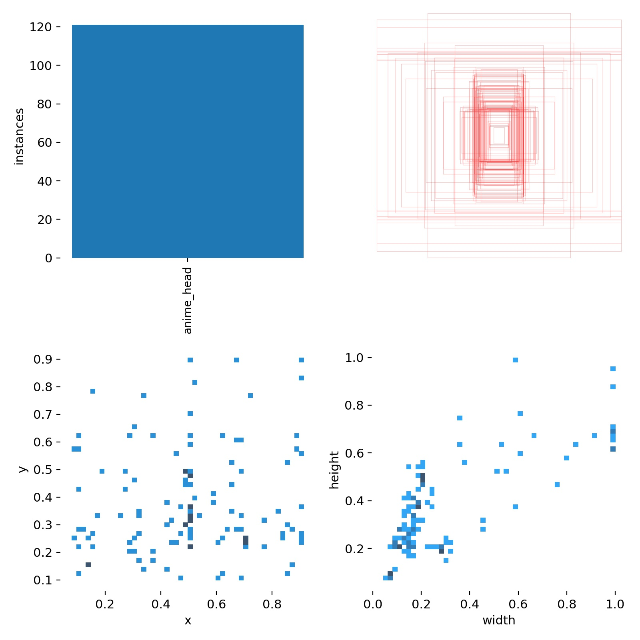

In [61]:
download_and_save(file_path="/content/yolov5/runs/train/exp/labels.jpg",
                  pretrained_model=pretrained_model,
                  download_file=True,
                  plot=True,
                  scale=0.4)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

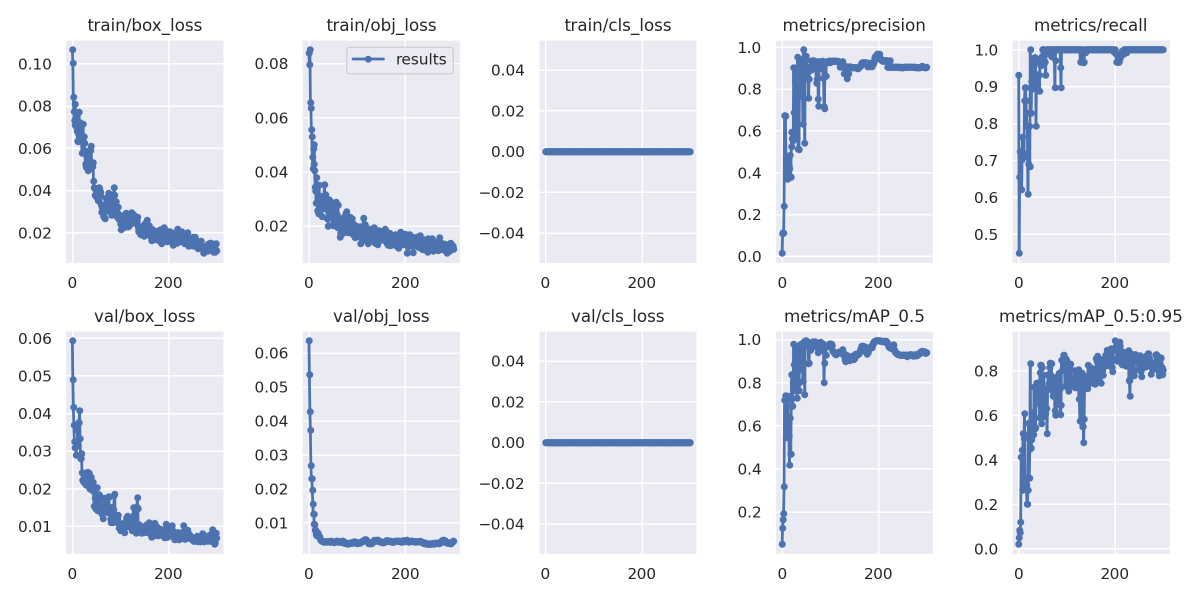

In [62]:
download_and_save(file_path="/content/yolov5/runs/train/exp/results.png",
                  pretrained_model=pretrained_model,
                  download_file=True,
                  plot=True,
                  scale=0.5
                  # save_to_drive=True,
                  # drive_save_path=drive_path_today)
                  )

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

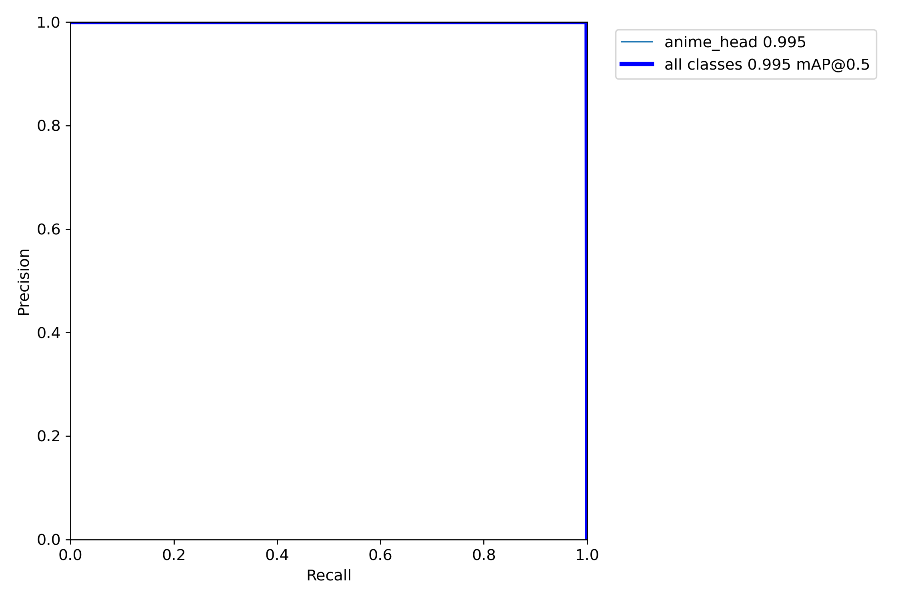

In [63]:
download_and_save(file_path="/content/yolov5/runs/train/exp/PR_curve.png",
                  pretrained_model=pretrained_model,
                  download_file=True,
                  plot=True,
                  scale=0.4)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

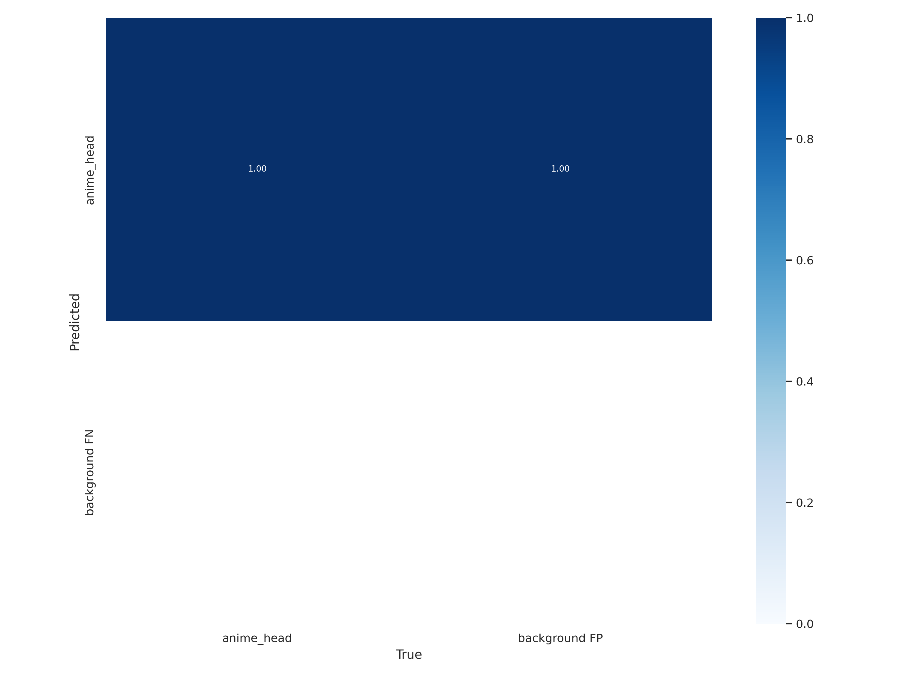

In [64]:
download_and_save(file_path="/content/yolov5/runs/train/exp/confusion_matrix.png",
                  pretrained_model=pretrained_model,
                  download_file=True,
                  plot=True,
                  scale=0.3)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

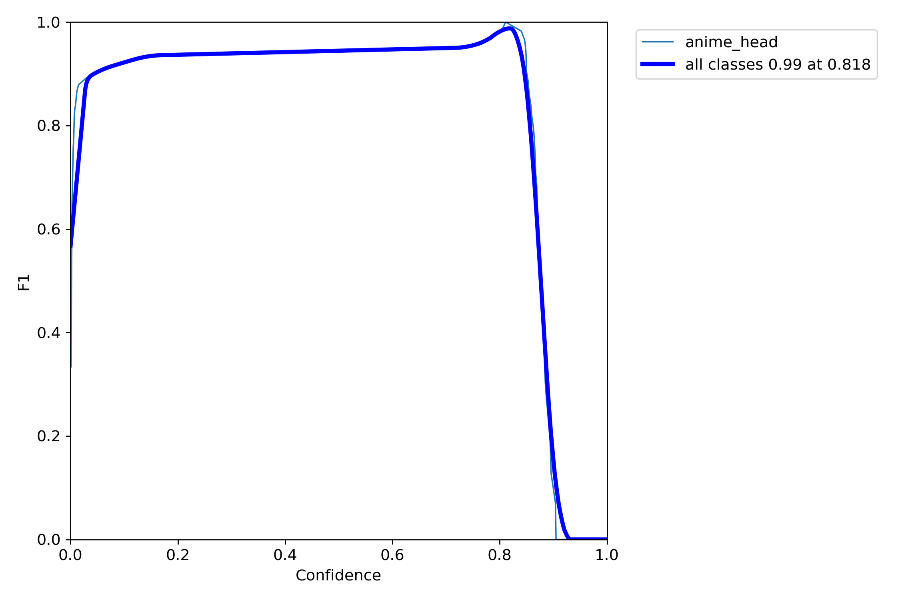

In [65]:
download_and_save(file_path="/content/yolov5/runs/train/exp/F1_curve.png",
                  pretrained_model=pretrained_model,
                  download_file=True,
                  plot=True,
                  scale=0.4)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

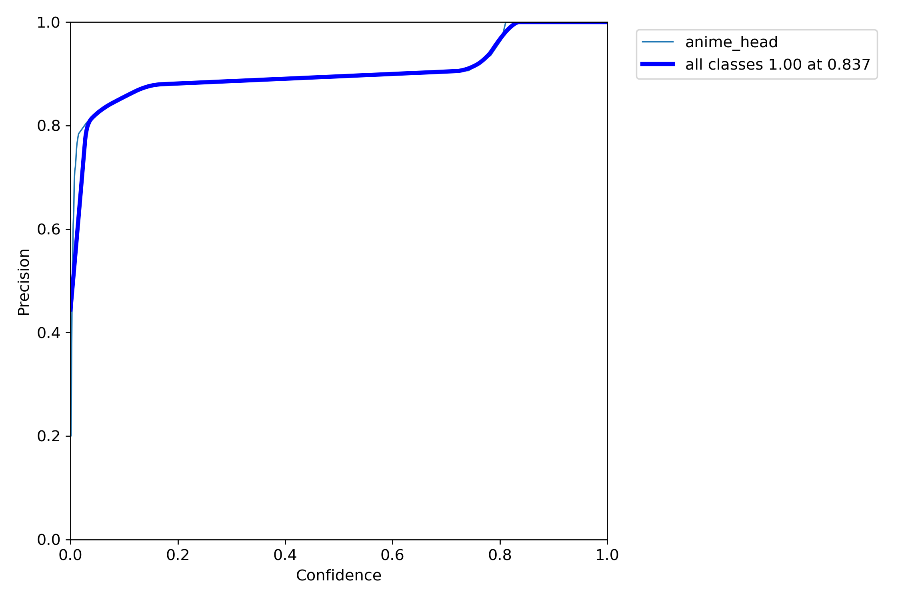

In [66]:
download_and_save(file_path="/content/yolov5/runs/train/exp/P_curve.png",
                  pretrained_model=pretrained_model,
                  download_file=True,
                  plot=True,
                  scale=0.4)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

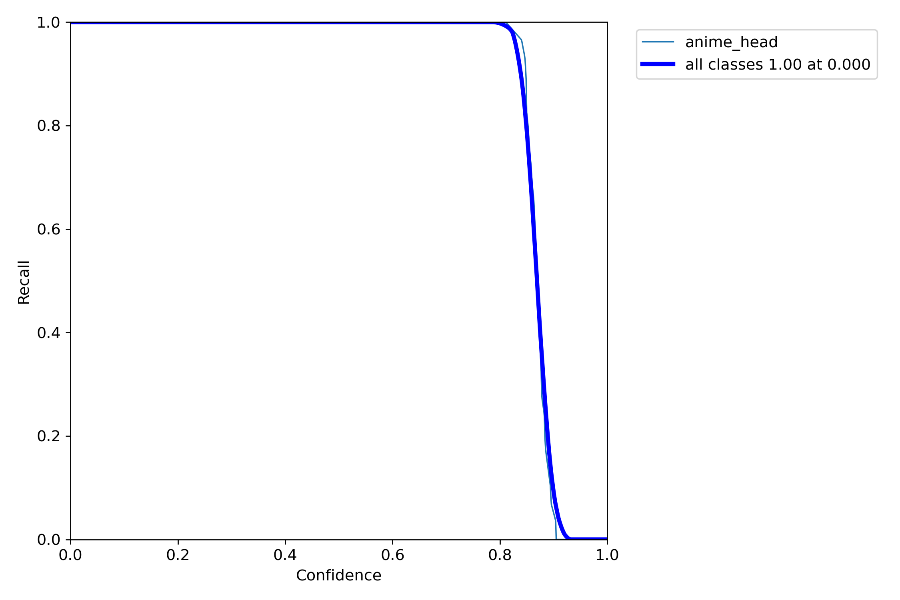

In [67]:
download_and_save(file_path="/content/yolov5/runs/train/exp/R_curve.png",
                  pretrained_model=pretrained_model,
                  download_file=True,
                  plot=True,
                  scale=0.4)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

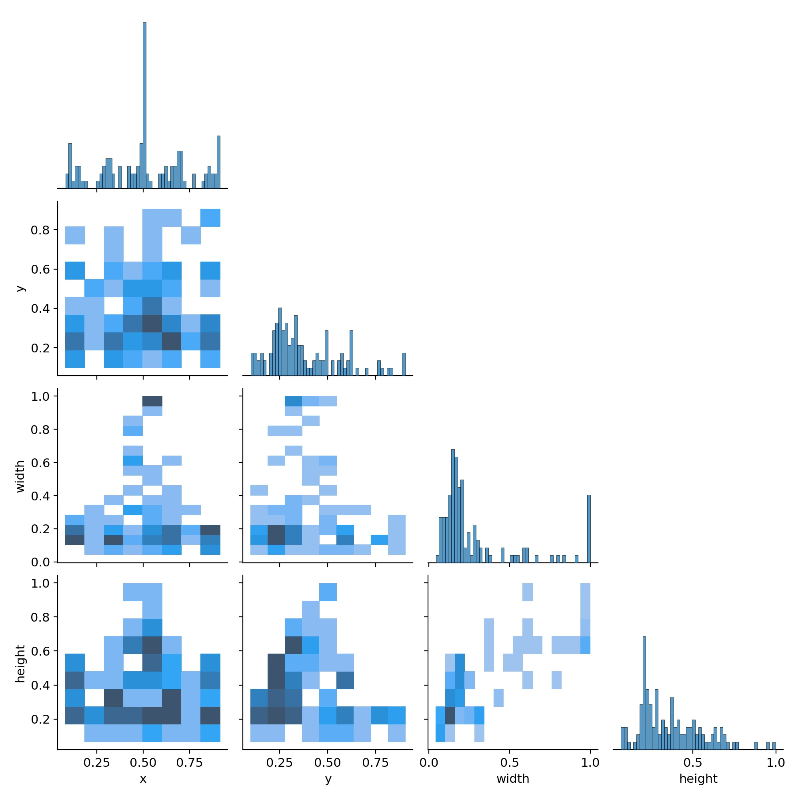

In [68]:
download_and_save(file_path="/content/yolov5/runs/train/exp/labels_correlogram.jpg",
                  pretrained_model=pretrained_model,
                  download_file=True,
                  plot=True,
                  scale=0.4)

# Test Model

In [69]:
exp = 1

In [70]:
def gen_image_path(exp, url, root_exp="/content/yolov5/runs/detect/exp"):
  if exp == 1:
    path = os.path.join(root_exp, url.split("/")[-1])
    exp += 1
  else:
    root_exp = f"{root_exp}{exp}"
    path = os.path.join(root_exp, url.split("/")[-1])
    exp += 1
  
  return exp, path

detect: weights=['/content/yolov5/2022.06.20/2022.06.20-YOLOv5x6_1280-Anime_Head_Detection.pt'], source=https://i.pinimg.com/236x/d2/6b/8d/d26b8d5b5722a66de3bfce6014db337a.jpg, data=data/coco128.yaml, imgsz=[640, 640], conf_thres=0.25, iou_thres=0.45, max_det=1000, device=, view_img=False, save_txt=False, save_conf=False, save_crop=False, nosave=False, classes=None, agnostic_nms=False, augment=False, visualize=False, update=False, project=runs/detect, name=exp, exist_ok=False, line_thickness=3, hide_labels=False, hide_conf=False, half=False, dnn=False
100% 13.4k/13.4k [00:00<00:00, 44.5MB/s]
YOLOv5 🚀 v6.1-258-g1156a32 Python-3.7.13 torch-1.11.0+cu113 CUDA:0 (Tesla P100-PCIE-16GB, 16281MiB)

Fusing layers... 
Model summary: 574 layers, 139970872 parameters, 0 gradients
image 1/1 /content/yolov5/d26b8d5b5722a66de3bfce6014db337a.jpg: 640x640 1 anime_head, Done. (0.039s)
Speed: 0.5ms pre-process, 39.0ms inference, 1.2ms NMS per image at shape (1, 3, 640, 640)
Results saved to runs/detect/e

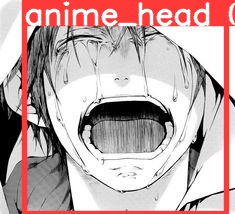

In [71]:
url = "https://i.pinimg.com/236x/d2/6b/8d/d26b8d5b5722a66de3bfce6014db337a.jpg"

exp, file_path = gen_image_path(exp=exp,url=url)
!python detect.py --weights {pretrained_model} --source {url}
Image(filename=file_path, width=600)

detect: weights=['/content/yolov5/2022.06.20/2022.06.20-YOLOv5x6_1280-Anime_Head_Detection.pt'], source=https://animeeverything.online/wp-content/uploads/2022/01/sad-anime-girl-crying-gifs.jpg, data=data/coco128.yaml, imgsz=[640, 640], conf_thres=0.25, iou_thres=0.45, max_det=1000, device=, view_img=False, save_txt=False, save_conf=False, save_crop=False, nosave=False, classes=None, agnostic_nms=False, augment=False, visualize=False, update=False, project=runs/detect, name=exp, exist_ok=False, line_thickness=3, hide_labels=False, hide_conf=False, half=False, dnn=False
42.1kB [00:00, 34.8MB/s]
YOLOv5 🚀 v6.1-258-g1156a32 Python-3.7.13 torch-1.11.0+cu113 CUDA:0 (Tesla P100-PCIE-16GB, 16281MiB)

Fusing layers... 
Model summary: 574 layers, 139970872 parameters, 0 gradients
image 1/1 /content/yolov5/sad-anime-girl-crying-gifs.jpg: 384x640 1 anime_head, Done. (0.031s)
Speed: 0.5ms pre-process, 30.7ms inference, 1.2ms NMS per image at shape (1, 3, 640, 640)
Results saved to runs/detect/exp2


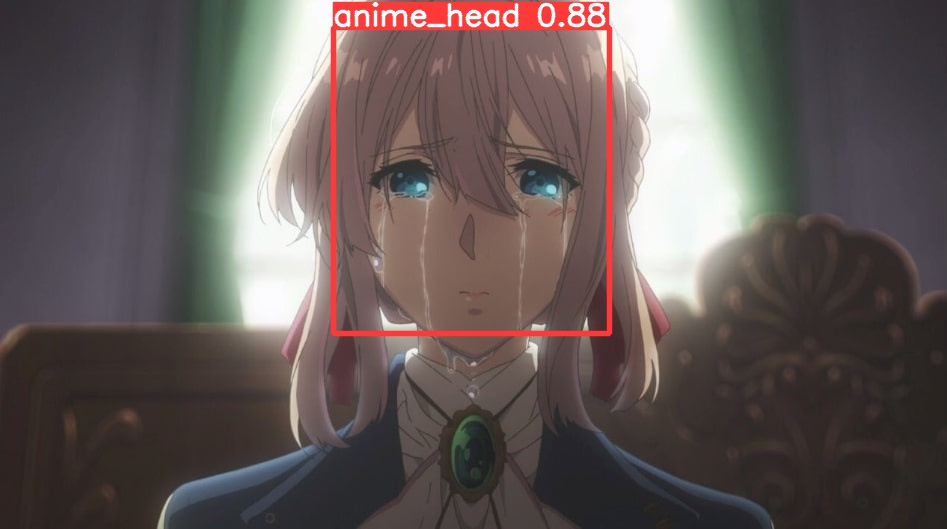

In [72]:
url = "https://animeeverything.online/wp-content/uploads/2022/01/sad-anime-girl-crying-gifs.jpg"

exp, file_path = gen_image_path(exp=exp,url=url)
!python detect.py --weights {pretrained_model} --source {url}
Image(filename=file_path, width=600)

detect: weights=['/content/yolov5/2022.06.20/2022.06.20-YOLOv5x6_1280-Anime_Head_Detection.pt'], source=https://i.pinimg.com/736x/07/fd/bf/07fdbfb2fa1e7ea73e97197a743a0bed.jpg, data=data/coco128.yaml, imgsz=[640, 640], conf_thres=0.25, iou_thres=0.45, max_det=1000, device=, view_img=False, save_txt=False, save_conf=False, save_crop=False, nosave=False, classes=None, agnostic_nms=False, augment=False, visualize=False, update=False, project=runs/detect, name=exp, exist_ok=False, line_thickness=3, hide_labels=False, hide_conf=False, half=False, dnn=False
Found https://i.pinimg.com/736x/07/fd/bf/07fdbfb2fa1e7ea73e97197a743a0bed.jpg locally at 07fdbfb2fa1e7ea73e97197a743a0bed.jpg
YOLOv5 🚀 v6.1-258-g1156a32 Python-3.7.13 torch-1.11.0+cu113 CUDA:0 (Tesla P100-PCIE-16GB, 16281MiB)

Fusing layers... 
Model summary: 574 layers, 139970872 parameters, 0 gradients
image 1/1 /content/yolov5/07fdbfb2fa1e7ea73e97197a743a0bed.jpg: 640x640 1 anime_head, Done. (0.042s)
Speed: 0.6ms pre-process, 41.8ms in

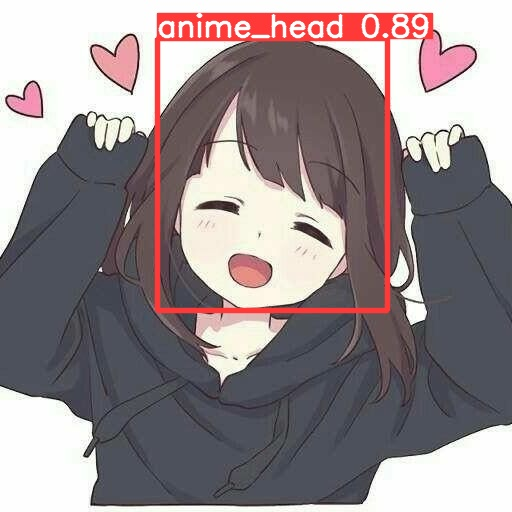

In [87]:
url = "https://i.pinimg.com/736x/07/fd/bf/07fdbfb2fa1e7ea73e97197a743a0bed.jpg"

exp, file_path = gen_image_path(exp=exp,url=url)
!python detect.py --weights {pretrained_model} --source {url}
Image(filename=file_path, width=600)

detect: weights=['/content/yolov5/2022.06.20/2022.06.20-YOLOv5x6_1280-Anime_Head_Detection.pt'], source=https://animemotivation.com/wp-content/uploads/2018/08/happy-anime-girl-cute-wallpaper.jpg, data=data/coco128.yaml, imgsz=[640, 640], conf_thres=0.25, iou_thres=0.45, max_det=1000, device=, view_img=False, save_txt=False, save_conf=False, save_crop=False, nosave=False, classes=None, agnostic_nms=False, augment=False, visualize=False, update=False, project=runs/detect, name=exp, exist_ok=False, line_thickness=3, hide_labels=False, hide_conf=False, half=False, dnn=False
Found https://animemotivation.com/wp-content/uploads/2018/08/happy-anime-girl-cute-wallpaper.jpg locally at happy-anime-girl-cute-wallpaper.jpg
YOLOv5 🚀 v6.1-258-g1156a32 Python-3.7.13 torch-1.11.0+cu113 CUDA:0 (Tesla P100-PCIE-16GB, 16281MiB)

Fusing layers... 
Model summary: 574 layers, 139970872 parameters, 0 gradients
image 1/1 /content/yolov5/happy-anime-girl-cute-wallpaper.jpg: 448x640 1 anime_head, Done. (0.041s)

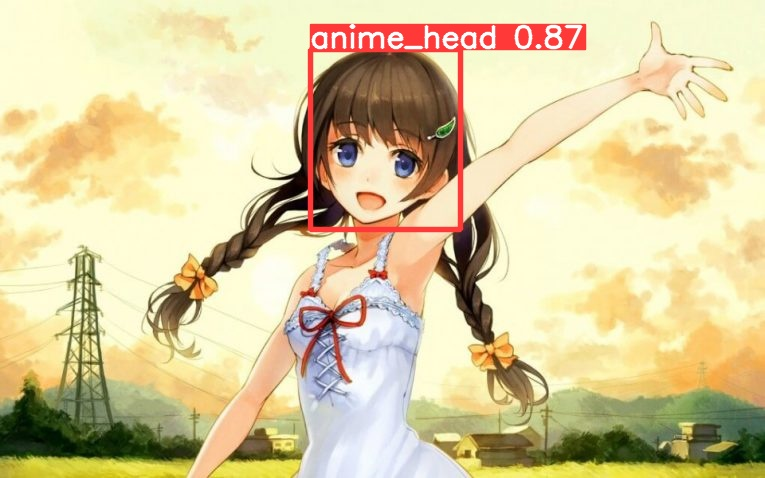

In [88]:
url = "https://animemotivation.com/wp-content/uploads/2018/08/happy-anime-girl-cute-wallpaper.jpg"

exp, file_path = gen_image_path(exp=exp,url=url)
!python detect.py --weights {pretrained_model} --source {url}
Image(filename=file_path, width=600)

detect: weights=['/content/yolov5/2022.06.20/2022.06.20-YOLOv5x6_1280-Anime_Head_Detection.pt'], source=https://cdn130.picsart.com/329465064025201.jpg, data=data/coco128.yaml, imgsz=[640, 640], conf_thres=0.25, iou_thres=0.45, max_det=1000, device=, view_img=False, save_txt=False, save_conf=False, save_crop=False, nosave=False, classes=None, agnostic_nms=False, augment=False, visualize=False, update=False, project=runs/detect, name=exp, exist_ok=False, line_thickness=3, hide_labels=False, hide_conf=False, half=False, dnn=False
100% 183k/183k [00:00<00:00, 12.3MB/s]
YOLOv5 🚀 v6.1-258-g1156a32 Python-3.7.13 torch-1.11.0+cu113 CUDA:0 (Tesla P100-PCIE-16GB, 16281MiB)

Fusing layers... 
Model summary: 574 layers, 139970872 parameters, 0 gradients
image 1/1 /content/yolov5/329465064025201.jpg: 640x640 1 anime_head, Done. (0.041s)
Speed: 0.6ms pre-process, 41.2ms inference, 1.4ms NMS per image at shape (1, 3, 640, 640)
Results saved to runs/detect/exp5


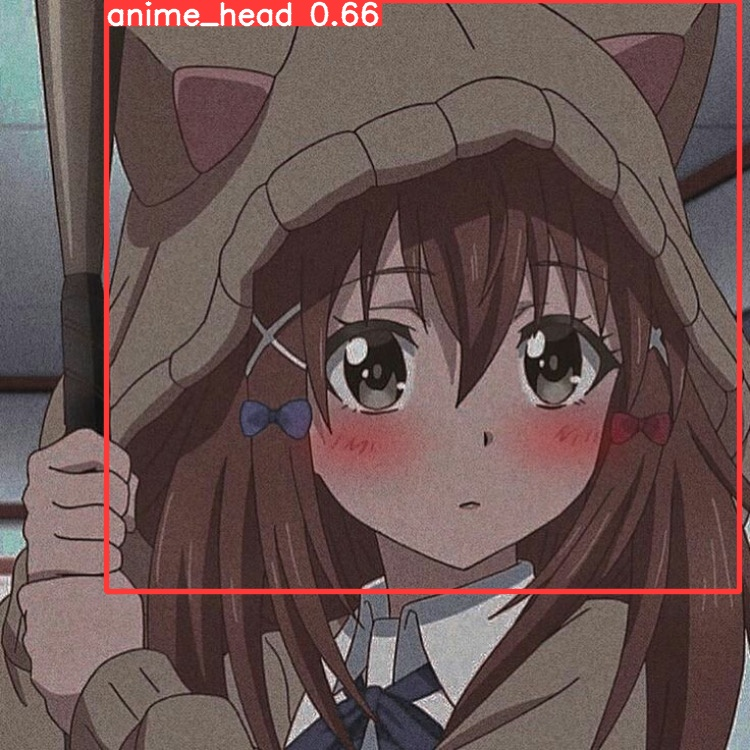

In [75]:
url = "https://cdn130.picsart.com/329465064025201.jpg" 

exp, file_path = gen_image_path(exp=exp,url=url)
!python detect.py --weights {pretrained_model} --source {url}
Image(filename=file_path, width=600)

detect: weights=['/content/yolov5/2022.06.20/2022.06.20-YOLOv5x6_1280-Anime_Head_Detection.pt'], source=https://img-9gag-fun.9cache.com/photo/azMP4nK_460s.jpg, data=data/coco128.yaml, imgsz=[640, 640], conf_thres=0.25, iou_thres=0.45, max_det=1000, device=, view_img=False, save_txt=False, save_conf=False, save_crop=False, nosave=False, classes=None, agnostic_nms=False, augment=False, visualize=False, update=False, project=runs/detect, name=exp, exist_ok=False, line_thickness=3, hide_labels=False, hide_conf=False, half=False, dnn=False
Found https://img-9gag-fun.9cache.com/photo/azMP4nK_460s.jpg locally at azMP4nK_460s.jpg
YOLOv5 🚀 v6.1-258-g1156a32 Python-3.7.13 torch-1.11.0+cu113 CUDA:0 (Tesla P100-PCIE-16GB, 16281MiB)

Fusing layers... 
Model summary: 574 layers, 139970872 parameters, 0 gradients
image 1/1 /content/yolov5/azMP4nK_460s.jpg: 384x640 2 anime_heads, Done. (0.034s)
Speed: 0.4ms pre-process, 33.6ms inference, 1.3ms NMS per image at shape (1, 3, 640, 640)
Results saved to r

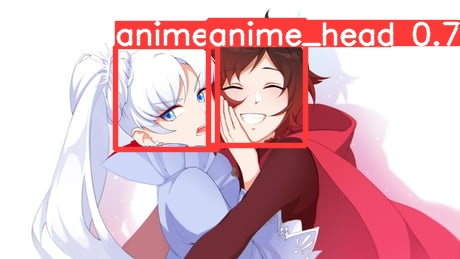

In [89]:
url = "https://img-9gag-fun.9cache.com/photo/azMP4nK_460s.jpg"

exp, file_path = gen_image_path(exp=exp,url=url)
!python detect.py --weights {pretrained_model} --source {url}
Image(filename=file_path, width=600)

detect: weights=['/content/yolov5/2022.06.20/2022.06.20-YOLOv5x6_1280-Anime_Head_Detection.pt'], source=https://w0.peakpx.com/wallpaper/198/41/HD-wallpaper-blushes-shy-expression-cute-anime-girl-twintails-red-eyes-anime.jpg, data=data/coco128.yaml, imgsz=[640, 640], conf_thres=0.25, iou_thres=0.45, max_det=1000, device=, view_img=False, save_txt=False, save_conf=False, save_crop=False, nosave=False, classes=None, agnostic_nms=False, augment=False, visualize=False, update=False, project=runs/detect, name=exp, exist_ok=False, line_thickness=3, hide_labels=False, hide_conf=False, half=False, dnn=False
Found https://w0.peakpx.com/wallpaper/198/41/HD-wallpaper-blushes-shy-expression-cute-anime-girl-twintails-red-eyes-anime.jpg locally at HD-wallpaper-blushes-shy-expression-cute-anime-girl-twintails-red-eyes-anime.jpg
YOLOv5 🚀 v6.1-258-g1156a32 Python-3.7.13 torch-1.11.0+cu113 CUDA:0 (Tesla P100-PCIE-16GB, 16281MiB)

Fusing layers... 
Model summary: 574 layers, 139970872 parameters, 0 gradie

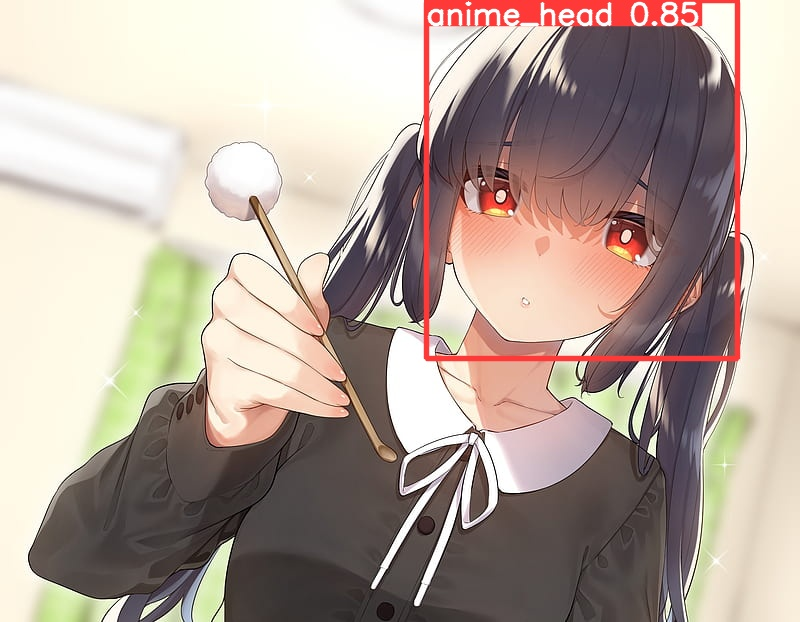

In [90]:
url = "https://w0.peakpx.com/wallpaper/198/41/HD-wallpaper-blushes-shy-expression-cute-anime-girl-twintails-red-eyes-anime.jpg"

exp, file_path = gen_image_path(exp=exp,url=url)
!python detect.py --weights {pretrained_model} --source {url}
Image(filename=file_path, width=600)

detect: weights=['/content/yolov5/2022.06.20/2022.06.20-YOLOv5x6_1280-Anime_Head_Detection.pt'], source=https://neocoill.com/wp/wp-content/uploads/2020/08/PlusUltraDate2-2_PUBLIC-601x850.jpg, data=data/coco128.yaml, imgsz=[640, 640], conf_thres=0.25, iou_thres=0.45, max_det=1000, device=, view_img=False, save_txt=False, save_conf=False, save_crop=False, nosave=False, classes=None, agnostic_nms=False, augment=False, visualize=False, update=False, project=runs/detect, name=exp, exist_ok=False, line_thickness=3, hide_labels=False, hide_conf=False, half=False, dnn=False
Found https://neocoill.com/wp/wp-content/uploads/2020/08/PlusUltraDate2-2_PUBLIC-601x850.jpg locally at PlusUltraDate2-2_PUBLIC-601x850.jpg
YOLOv5 🚀 v6.1-258-g1156a32 Python-3.7.13 torch-1.11.0+cu113 CUDA:0 (Tesla P100-PCIE-16GB, 16281MiB)

Fusing layers... 
Model summary: 574 layers, 139970872 parameters, 0 gradients
image 1/1 /content/yolov5/PlusUltraDate2-2_PUBLIC-601x850.jpg: 640x512 1 anime_head, Done. (0.035s)
Speed: 

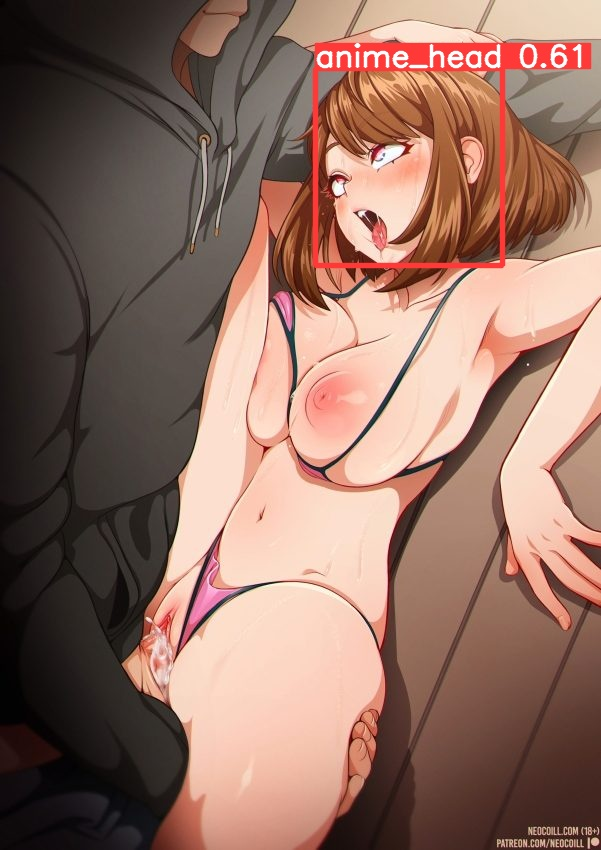

In [91]:
url = "https://neocoill.com/wp/wp-content/uploads/2020/08/PlusUltraDate2-2_PUBLIC-601x850.jpg"

exp, file_path = gen_image_path(exp=exp,url=url)
!python detect.py --weights {pretrained_model} --source {url}
Image(filename=file_path, width=600)

detect: weights=['/content/yolov5/2022.06.20/2022.06.20-YOLOv5x6_1280-Anime_Head_Detection.pt'], source=https://cdn.wallpapersafari.com/10/84/62a1Qi.png, data=data/coco128.yaml, imgsz=[640, 640], conf_thres=0.25, iou_thres=0.45, max_det=1000, device=, view_img=False, save_txt=False, save_conf=False, save_crop=False, nosave=False, classes=None, agnostic_nms=False, augment=False, visualize=False, update=False, project=runs/detect, name=exp, exist_ok=False, line_thickness=3, hide_labels=False, hide_conf=False, half=False, dnn=False
Found https://cdn.wallpapersafari.com/10/84/62a1Qi.png locally at 62a1Qi.png
YOLOv5 🚀 v6.1-258-g1156a32 Python-3.7.13 torch-1.11.0+cu113 CUDA:0 (Tesla P100-PCIE-16GB, 16281MiB)

Fusing layers... 
Model summary: 574 layers, 139970872 parameters, 0 gradients
image 1/1 /content/yolov5/62a1Qi.png: 640x512 1 anime_head, Done. (0.035s)
Speed: 0.5ms pre-process, 34.9ms inference, 1.4ms NMS per image at shape (1, 3, 640, 640)
Results saved to runs/detect/exp20


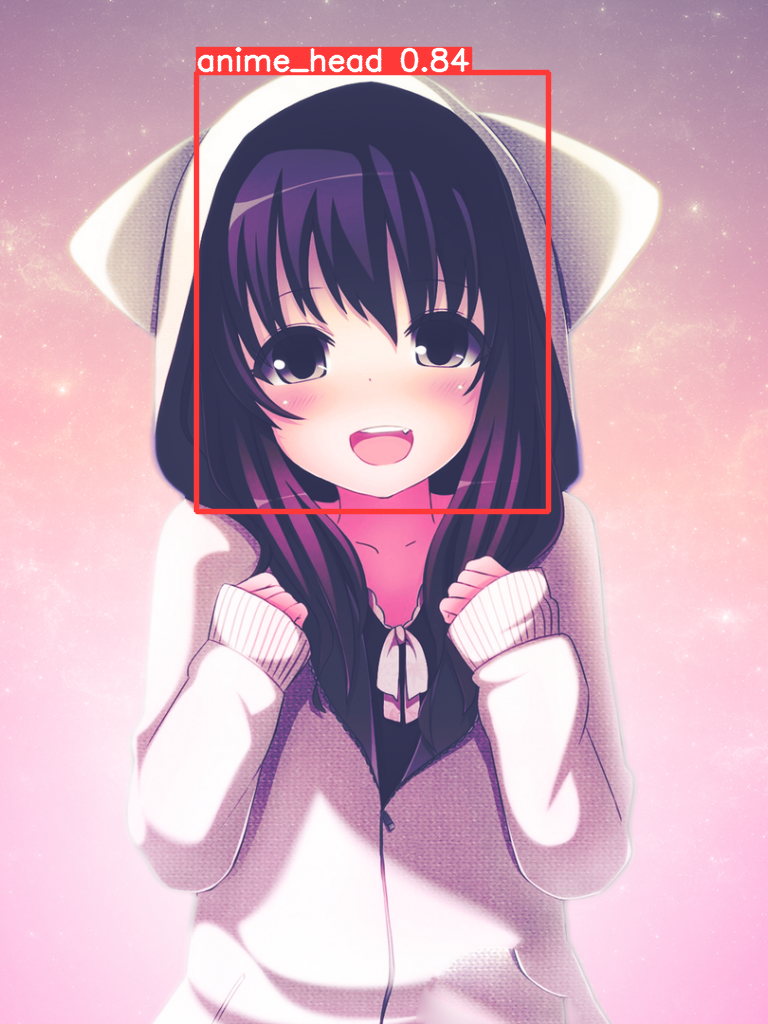

In [131]:
url = "https://cdn.wallpapersafari.com/10/84/62a1Qi.png"

exp, file_path = gen_image_path(exp=exp,url=url)
!python detect.py --weights {pretrained_model} --source {url}
Image(filename=file_path, width=600)

detect: weights=['/content/yolov5/2022.06.20/2022.06.20-YOLOv5x6_1280-Anime_Head_Detection.pt'], source=https://i.ytimg.com/vi/82xfy5BxM1U/maxresdefault.jpg, data=data/coco128.yaml, imgsz=[640, 640], conf_thres=0.25, iou_thres=0.45, max_det=1000, device=, view_img=False, save_txt=False, save_conf=False, save_crop=False, nosave=False, classes=None, agnostic_nms=False, augment=False, visualize=False, update=False, project=runs/detect, name=exp, exist_ok=False, line_thickness=3, hide_labels=False, hide_conf=False, half=False, dnn=False
Found https://i.ytimg.com/vi/82xfy5BxM1U/maxresdefault.jpg locally at maxresdefault.jpg
YOLOv5 🚀 v6.1-258-g1156a32 Python-3.7.13 torch-1.11.0+cu113 CUDA:0 (Tesla P100-PCIE-16GB, 16281MiB)

Fusing layers... 
Model summary: 574 layers, 139970872 parameters, 0 gradients
image 1/1 /content/yolov5/maxresdefault.jpg: 384x640 1 anime_head, Done. (0.034s)
Speed: 0.4ms pre-process, 33.7ms inference, 1.3ms NMS per image at shape (1, 3, 640, 640)
Results saved to runs

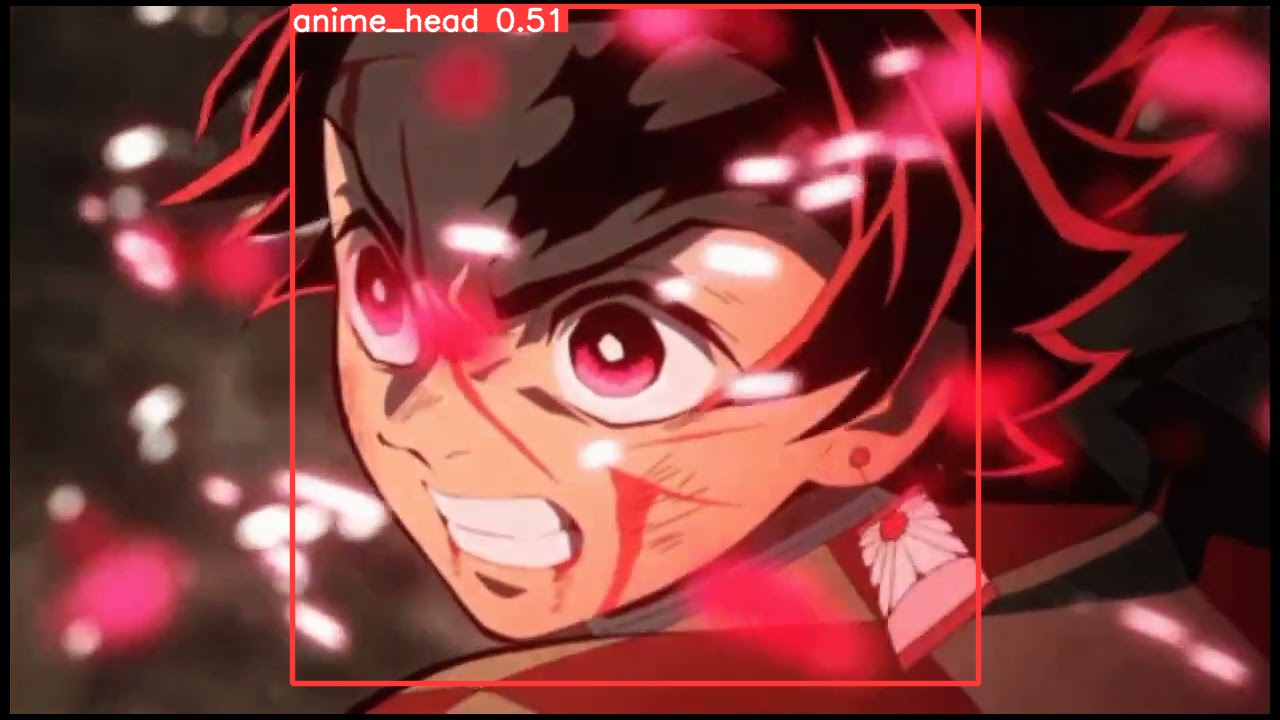

In [132]:
url = "https://i.ytimg.com/vi/82xfy5BxM1U/maxresdefault.jpg"

exp, file_path = gen_image_path(exp=exp,url=url)
!python detect.py --weights {pretrained_model} --source {url}
Image(filename=file_path, width=600)

detect: weights=['/content/yolov5/2022.06.20/2022.06.20-YOLOv5x6_1280-Anime_Head_Detection.pt'], source=https://pbs.twimg.com/media/FOyCxyvWYAQb1nF.jpg, data=data/coco128.yaml, imgsz=[640, 640], conf_thres=0.25, iou_thres=0.45, max_det=1000, device=, view_img=False, save_txt=False, save_conf=False, save_crop=False, nosave=False, classes=None, agnostic_nms=False, augment=False, visualize=False, update=False, project=runs/detect, name=exp, exist_ok=False, line_thickness=3, hide_labels=False, hide_conf=False, half=False, dnn=False
Found https://pbs.twimg.com/media/FOyCxyvWYAQb1nF.jpg locally at FOyCxyvWYAQb1nF.jpg
YOLOv5 🚀 v6.1-258-g1156a32 Python-3.7.13 torch-1.11.0+cu113 CUDA:0 (Tesla P100-PCIE-16GB, 16281MiB)

Fusing layers... 
Model summary: 574 layers, 139970872 parameters, 0 gradients
image 1/1 /content/yolov5/FOyCxyvWYAQb1nF.jpg: 384x640 1 anime_head, Done. (0.031s)
Speed: 0.4ms pre-process, 30.7ms inference, 1.2ms NMS per image at shape (1, 3, 640, 640)
Results saved to runs/detec

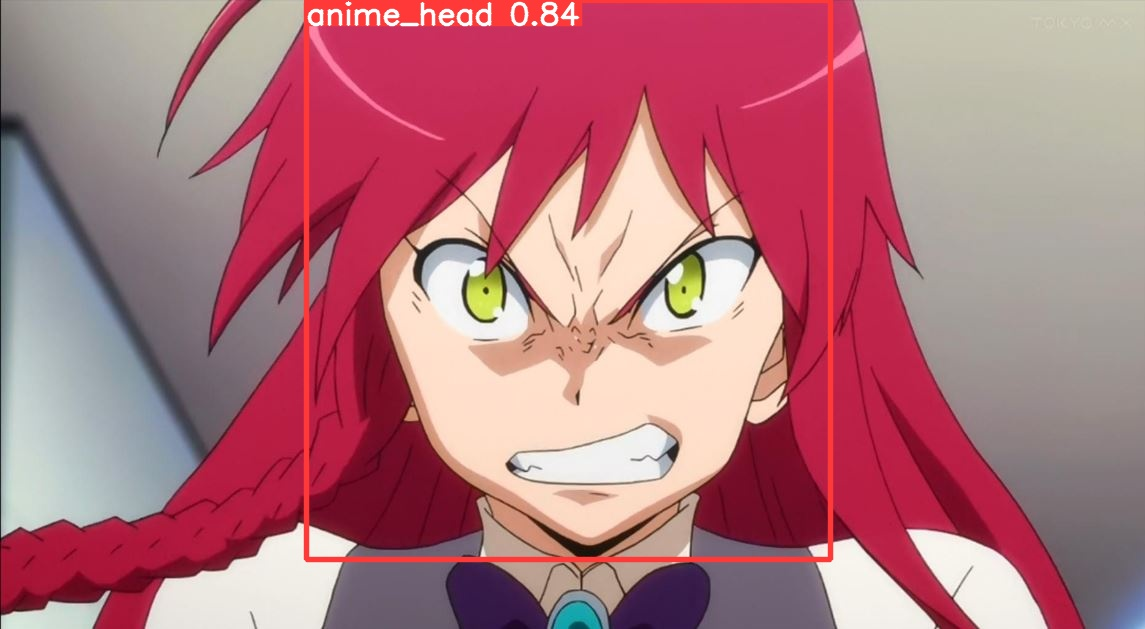

In [133]:
url = "https://pbs.twimg.com/media/FOyCxyvWYAQb1nF.jpg"

exp, file_path = gen_image_path(exp=exp,url=url)
!python detect.py --weights {pretrained_model} --source {url}
Image(filename=file_path, width=600)

detect: weights=['/content/yolov5/2022.06.20/2022.06.20-YOLOv5x6_1280-Anime_Head_Detection.pt'], source=https://wallpapercave.com/uwp/uwp2045491.jpeg, data=data/coco128.yaml, imgsz=[640, 640], conf_thres=0.25, iou_thres=0.45, max_det=1000, device=, view_img=False, save_txt=False, save_conf=False, save_crop=False, nosave=False, classes=None, agnostic_nms=False, augment=False, visualize=False, update=False, project=runs/detect, name=exp, exist_ok=False, line_thickness=3, hide_labels=False, hide_conf=False, half=False, dnn=False
Found https://wallpapercave.com/uwp/uwp2045491.jpeg locally at uwp2045491.jpeg
YOLOv5 🚀 v6.1-258-g1156a32 Python-3.7.13 torch-1.11.0+cu113 CUDA:0 (Tesla P100-PCIE-16GB, 16281MiB)

Fusing layers... 
Model summary: 574 layers, 139970872 parameters, 0 gradients
image 1/1 /content/yolov5/uwp2045491.jpeg: 320x640 1 anime_head, Done. (0.029s)
Speed: 0.4ms pre-process, 29.0ms inference, 1.2ms NMS per image at shape (1, 3, 640, 640)
Results saved to runs/detect/exp23


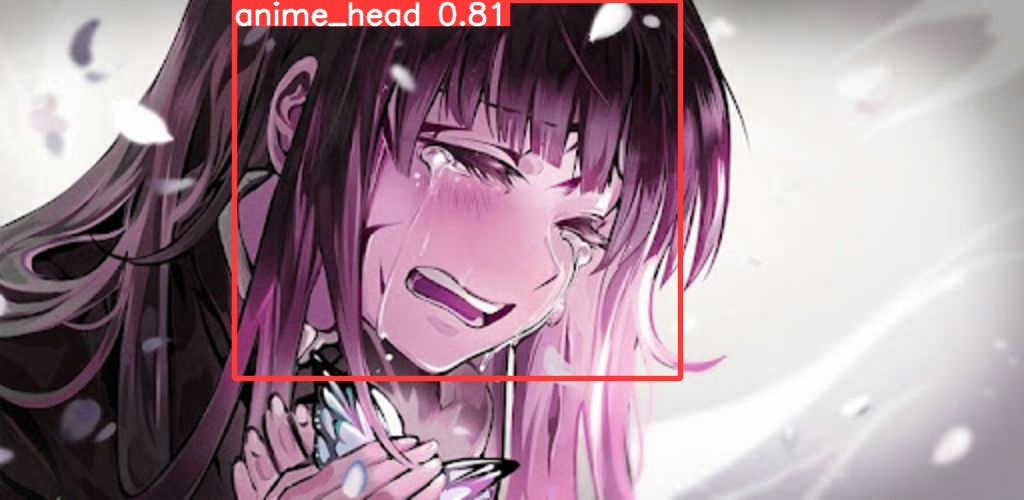

In [134]:
url = "https://wallpapercave.com/uwp/uwp2045491.jpeg"

exp, file_path = gen_image_path(exp=exp,url=url)
!python detect.py --weights {pretrained_model} --source {url}
Image(filename=file_path, width=600)

detect: weights=['/content/yolov5/2022.06.20/2022.06.20-YOLOv5x6_1280-Anime_Head_Detection.pt'], source=https://pm1.narvii.com/6110/3835c243db7e4453f0757d92d58d7f0fb076575c_hq.jpg, data=data/coco128.yaml, imgsz=[640, 640], conf_thres=0.25, iou_thres=0.45, max_det=1000, device=, view_img=False, save_txt=False, save_conf=False, save_crop=False, nosave=False, classes=None, agnostic_nms=False, augment=False, visualize=False, update=False, project=runs/detect, name=exp, exist_ok=False, line_thickness=3, hide_labels=False, hide_conf=False, half=False, dnn=False
Found https://pm1.narvii.com/6110/3835c243db7e4453f0757d92d58d7f0fb076575c_hq.jpg locally at 3835c243db7e4453f0757d92d58d7f0fb076575c_hq.jpg
YOLOv5 🚀 v6.1-258-g1156a32 Python-3.7.13 torch-1.11.0+cu113 CUDA:0 (Tesla P100-PCIE-16GB, 16281MiB)

Fusing layers... 
Model summary: 574 layers, 139970872 parameters, 0 gradients
image 1/1 /content/yolov5/3835c243db7e4453f0757d92d58d7f0fb076575c_hq.jpg: 384x640 1 anime_head, Done. (0.034s)
Speed

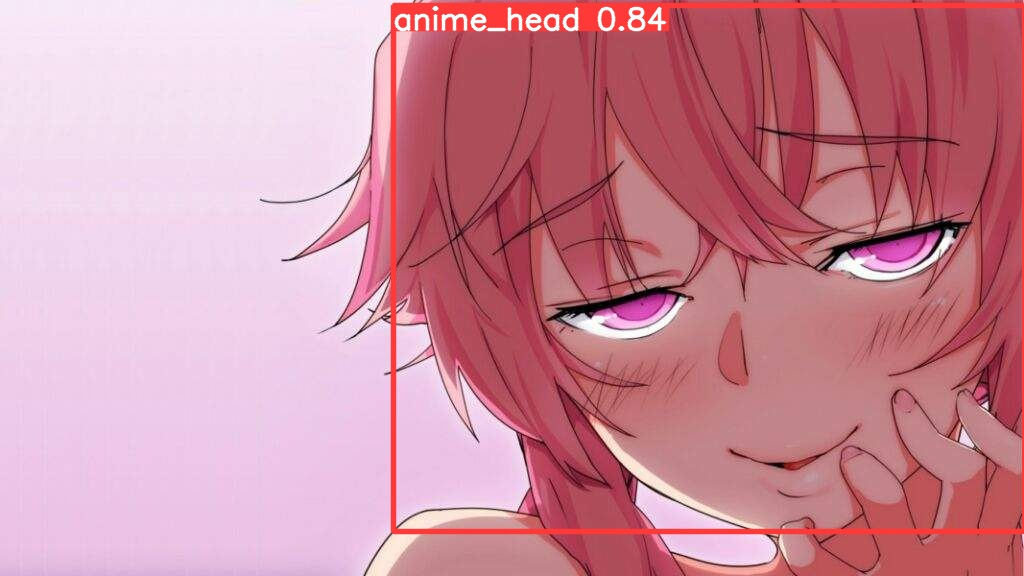

In [135]:
url = "https://pm1.narvii.com/6110/3835c243db7e4453f0757d92d58d7f0fb076575c_hq.jpg"

exp, file_path = gen_image_path(exp=exp,url=url)
!python detect.py --weights {pretrained_model} --source {url}
Image(filename=file_path, width=600)

detect: weights=['/content/yolov5/2022.06.20/2022.06.20-YOLOv5x6_1280-Anime_Head_Detection.pt'], source=https://i.pinimg.com/originals/4f/b2/da/4fb2dadfad8cb78df48468df2f72027d.jpg, data=data/coco128.yaml, imgsz=[640, 640], conf_thres=0.25, iou_thres=0.45, max_det=1000, device=, view_img=False, save_txt=False, save_conf=False, save_crop=False, nosave=False, classes=None, agnostic_nms=False, augment=False, visualize=False, update=False, project=runs/detect, name=exp, exist_ok=False, line_thickness=3, hide_labels=False, hide_conf=False, half=False, dnn=False
Found https://i.pinimg.com/originals/4f/b2/da/4fb2dadfad8cb78df48468df2f72027d.jpg locally at 4fb2dadfad8cb78df48468df2f72027d.jpg
YOLOv5 🚀 v6.1-258-g1156a32 Python-3.7.13 torch-1.11.0+cu113 CUDA:0 (Tesla P100-PCIE-16GB, 16281MiB)

Fusing layers... 
Model summary: 574 layers, 139970872 parameters, 0 gradients
image 1/1 /content/yolov5/4fb2dadfad8cb78df48468df2f72027d.jpg: 384x640 1 anime_head, Done. (0.034s)
Speed: 0.5ms pre-process,

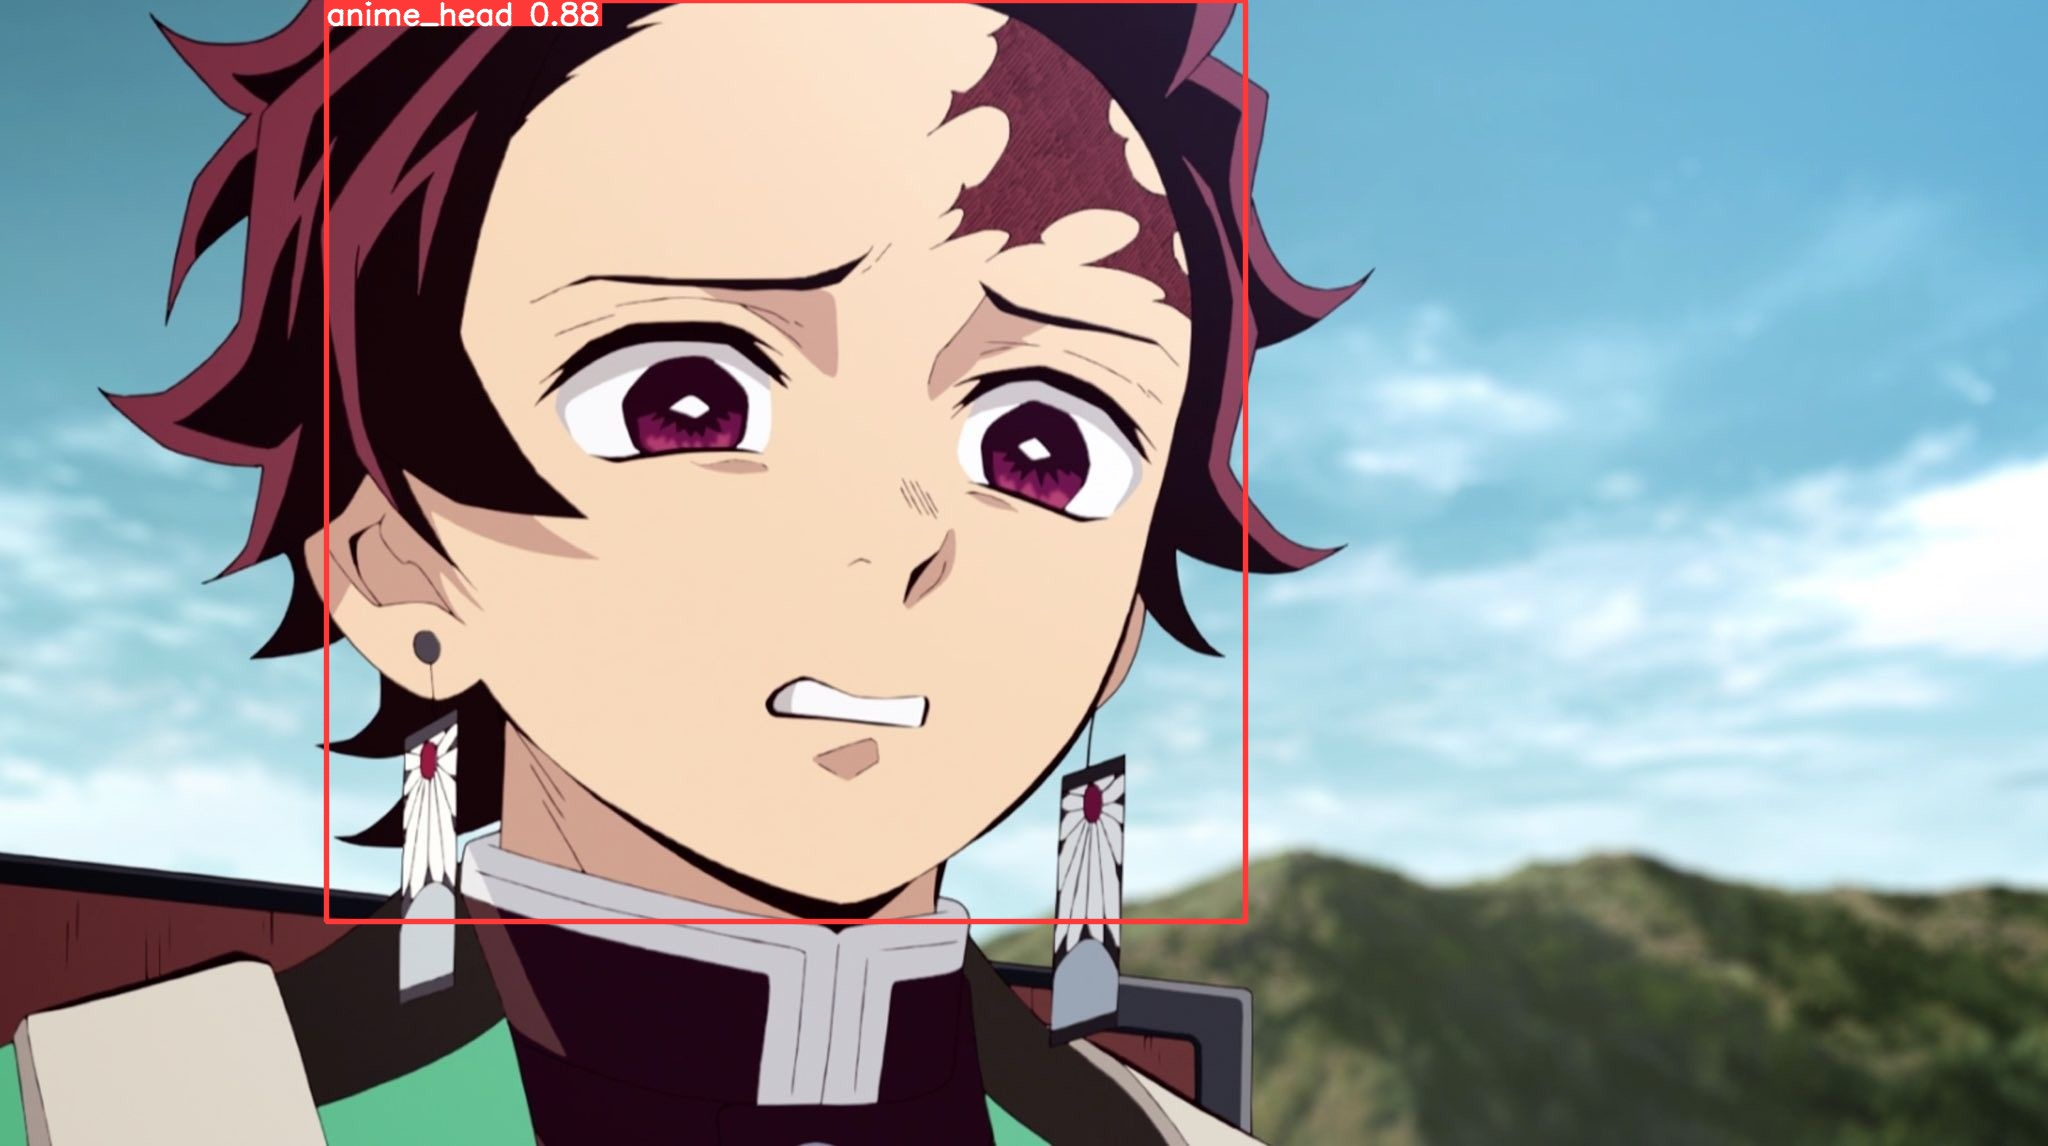

In [136]:
url = "https://i.pinimg.com/originals/4f/b2/da/4fb2dadfad8cb78df48468df2f72027d.jpg"

exp, file_path = gen_image_path(exp=exp,url=url)
!python detect.py --weights {pretrained_model} --source {url}
Image(filename=file_path, width=600)

# 16. Sleeping

In [ ]:
def int_to_str(seconds):
  hours = int(seconds / 3600)
  if hours == 0:
    time = ""
  elif hours < 10:
    time = f"0{hours}h"
  else:
    time = f"{hours}h"
  
  minutes = int(seconds / 60) - hours*60
  if minutes == 0 and hours == 0:
    time += ""
  elif minutes == 0 and hours != 0:
    time += "00m"
  elif minutes < 10:
    time += f"0{minutes}m"
  else:
    time += f"{minutes}m"

  seconds = seconds % 60
  if int(seconds) < 10:
    seconds = f"0{seconds}"
  time += f"{seconds}s"

  return time

In [86]:
sleep = 0

try :
    while(True):
        time.sleep(1)
        sleep += 1
        print("", end=f"\rSleeping... {int_to_str(sleep)}")
except:
    pass

Sleeping... 23m45s